# DAY 3 — Complete Pandas Tutorial

## What is Pandas?
**Pandas** is the most important Python library for data analysis.

The name comes from **Panel Data** (financial data term).

Think of Pandas as:
- **Excel** — but inside Python
- **SQL** — but without a database
- **Calculator** — but for entire tables of data

---

## What Will You Learn Today?

| Topic | What it Does |
|-------|-------------|
| Series | 1-column data (like a list with labels) |
| DataFrame | Full table (rows + columns) |
| File I/O | Read/Write CSV and Excel files |
| Inspection | Understand your data at a glance |
| Selection | Pick rows, columns, or specific cells |
| Missing Data | Find and fix blank/null values |
| Operations | Calculate new columns |
| GroupBy | Summarize data by groups |
| Merge | Join two tables together |
| Pivot Table | Summarize data like Excel pivot |
| Apply/Lambda | Apply custom logic to each row |
| Time Series | Work with date-based data |
| Plotting | Create charts directly from data |

---

> **Real-world use:** Every company — banks, hospitals, e-commerce, schools — uses Pandas-style analysis every day.

---
## STEP 1 — Import Required Libraries

Before doing anything in Python, we must **import** the libraries.

| Library | Short Name | Purpose |
|---------|-----------|---------|
| `pandas` | `pd` | Reading, cleaning, analyzing data tables |
| `numpy` | `np` | Math operations on arrays of numbers |
| `matplotlib.pyplot` | `plt` | Drawing charts and graphs |

**Why short names?**  
Writing `pd.DataFrame()` is much faster than `pandas.DataFrame()` every time.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


---
## STEP 2 — Pandas Series (1D Data)

### What is a Series?
A **Series** is a **single column** of data — like one column in an Excel sheet.

```
Index → Label    Value
  a   →          10
  b   →          20
  c   →          30
```

**Key Features:**
- Each value has an **index** (label)
- All values have the same data type
- You can use custom labels instead of 0, 1, 2

**Real-world examples of Series:**
- List of student names
- Daily temperatures
- Monthly sales figures

### Creating a Series from a List

In [2]:

s1 = pd.Series(
    [10,20,30,40,50,60],
    index=['a','b','c','d','e','f']
)

print(s1)


a    10
b    20
c    30
d    40
e    50
f    60
dtype: int64


**Understanding the Output:**
```
a    10   ← index 'a' has value 10
b    20
c    30
dtype: int64  ← all values are integers
```

---
### Creating a Series from a Dictionary

When you create a Series from a **dictionary**, the **keys become the index labels** automatically.

This is useful when your data already has named fields.

In [3]:

s2 = pd.Series({
    'math': 85,
    'science': 92,
    'english': 78
})

print(s2)


math       85
science    92
english    78
dtype: int64


---
## STEP 3 — Pandas DataFrame (2D Table)

### What is a DataFrame?
A **DataFrame** is a **full table** — rows AND columns, just like an Excel spreadsheet or SQL table.

```
     Name   Age    City   Score
0   Alice    25     NYC      85   ← Row 0
1     Bob    30      LA      92   ← Row 1
2 Charlie    35  Chicago      78   ← Row 2
3   Diana    28     NYC      88   ← Row 3
↑ Index     ↑ Columns (each is a Series)
```

**Key facts:**
- Each **column** is a Series
- Each **row** is one record (one person, one order, one product)
- Rows have numeric index (0, 1, 2...) by default

### Creating a DataFrame from a Dictionary

Each **key** = column name  
Each **value** (list) = column data

In [4]:

data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana'],
    'Age': [25, 30, 35, 28],
    'City': ['NYC', 'LA', 'Chicago', 'NYC'],
    'Score': [85, 92, 78, 88]
}

df = pd.DataFrame(data)

print(df)


      Name  Age     City  Score
0    Alice   25      NYC     85
1      Bob   30       LA     92
2  Charlie   35  Chicago     78
3    Diana   28      NYC     88


---
### Creating a DataFrame from a List of Tuples

Each **tuple** = one row of data.  
You must provide `columns=` to name the columns.

**When to use this format?**  
When your data comes as a list of records (tuples), e.g. from a database query.

In [5]:

df2 = pd.DataFrame(
    [(1, 'ram'), (2, 'shyam')],
    columns=['ID', 'name']
)

print(df2)


   ID   name
0   1    ram
1   2  shyam


---
## STEP 4 — File Operations (Reading & Writing)

### Why is this important?
In real life, data comes from **files** — not typed manually in code.

| Function | What it does |
|----------|-------------|
| `df.to_csv('file.csv')` | Save DataFrame as a CSV file |
| `pd.read_csv('file.csv')` | Load a CSV file into DataFrame |
| `df.to_excel('file.xlsx')` | Save as Excel file |
| `pd.read_excel('file.xlsx')` | Load an Excel file |

**`index=False`** — Do NOT write the row numbers (0,1,2..) into the file.  
If you leave this out, the file gets an extra unwanted column called "Unnamed: 0".

> **Real-world:** Analysts get data as `.csv` files from clients, clean it in Python, and send back a clean `.xlsx` report.

In [6]:

df.to_csv('students.csv', index=False)
print("CSV file saved")

df.to_excel('students.xlsx', index=False)
print("Excel file saved")


CSV file saved
Excel file saved


---
## STEP 5 — Basic Data Inspection

### First thing to do when you get new data!

When a data analyst receives any dataset, they always run these 6 commands first to understand the data:

| Function | What it shows | Use case |
|----------|--------------|---------|
| `df.head(n)` | First n rows (default 5) | Quick preview |
| `df.tail(n)` | Last n rows | Check end of data |
| `df.info()` | Column names, types, missing count | Data quality check |
| `df.describe()` | Min, max, mean, std of numbers | Statistical overview |
| `df.shape` | (rows, columns) | Size of data |
| `df.columns` | Column names list | Know available columns |

> **Think of it like opening a new file at work** — you first skim through it before doing anything.

### `head()` — See First Rows

In [7]:

print(df.head(2))


    Name  Age City  Score
0  Alice   25  NYC     85
1    Bob   30   LA     92


In [8]:

print(df.tail(2))


      Name  Age     City  Score
2  Charlie   35  Chicago     78
3    Diana   28      NYC     88


### `tail()` — See Last Rows

Useful to check if data ends correctly — no junk rows at the bottom.

In [9]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    4 non-null      object
 1   Age     4 non-null      int64 
 2   City    4 non-null      object
 3   Score   4 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 260.0+ bytes


### `info()` — Column Details & Data Types

**This is the most important inspection command.**

It shows:
- Column names
- How many non-null (non-missing) values exist
- Data type of each column (`object` = text, `int64` = integer, `float64` = decimal)

**Reading the output:**
```
Non-Null Count  Dtype
4 non-null      object   ← text column, all 4 rows have values
4 non-null      int64    ← number column, all 4 rows have values
```
If you see `3 non-null` in a 4-row dataset → **1 value is missing (NaN)**

In [10]:

print(df.describe())


             Age      Score
count   4.000000   4.000000
mean   29.500000  85.750000
std     4.203173   5.909033
min    25.000000  78.000000
25%    27.250000  83.250000
50%    29.000000  86.500000
75%    31.250000  89.000000
max    35.000000  92.000000


### `describe()` — Statistical Summary

Gives you **8 statistics** for every numeric column automatically:

| Stat | Meaning |
|------|---------|
| `count` | How many values (not missing) |
| `mean` | Average value |
| `std` | Standard deviation — how spread out the data is |
| `min` | Smallest value |
| `25%` | 25th percentile — bottom quarter |
| `50%` | Median — middle value |
| `75%` | 75th percentile — top quarter |
| `max` | Largest value |

> **Note:** `describe()` only shows **numeric columns** by default. Text columns are skipped.

In [11]:

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Index:", df.index)


Shape: (4, 4)
Columns: ['Name', 'Age', 'City', 'Score']
Index: RangeIndex(start=0, stop=4, step=1)


### `shape`, `columns`, `index`

```python
df.shape    → (4, 4)  ← 4 rows, 4 columns
df.columns  → ['Name', 'Age', 'City', 'Score']
df.index    → RangeIndex(start=0, stop=4, step=1)  ← row labels 0,1,2,3
```

**Use `df.shape[0]`** to get only the row count (useful in loops and conditions).

---
## STEP 6 — Selecting Data

### 4 Ways to Select Data

| Method | Selects | Example |
|--------|---------|---------|
| `df['Col']` | Single column | `df['Name']` |
| `df[['Col1','Col2']]` | Multiple columns | `df[['Name','Score']]` |
| `df.iloc[row, col]` | By **position** (number) | `df.iloc[1]` = 2nd row |
| `df.loc[label]` | By **label** (name/index) | `df.loc[1]` = row with index 1 |
| `df[condition]` | Filter rows | `df[df['Score'] > 80]` |

---
### Single Column Selection — `df['ColumnName']`

Returns a **Series** (one column).

In [12]:

print(df['Name'])


0      Alice
1        Bob
2    Charlie
3      Diana
Name: Name, dtype: object


In [13]:

print(df[['Name', 'Score']])


      Name  Score
0    Alice     85
1      Bob     92
2  Charlie     78
3    Diana     88


### Multiple Columns — `df[['Col1', 'Col2']]`

Use **double brackets** `[[]]` to select more than one column.  
Returns a **DataFrame** (not a Series).

> **Common mistake:** Using single brackets `df['Name','Score']` → This will throw a KeyError!

In [14]:

print(df.iloc[1])


Name     Bob
Age       30
City      LA
Score     92
Name: 1, dtype: object


### `iloc` vs `loc` — Row Selection

| | `iloc` | `loc` |
|--|--------|-------|
| Full name | Integer Location | Label Location |
| Uses | Position numbers (0,1,2...) | Index labels |
| Think of it as | Row number in a class register | Student roll number |

**`iloc[1]`** → "Give me the 2nd row" (0-indexed, so position 1)  
**`loc[1]`** → "Give me the row whose index label is 1"

When index is default (0,1,2...), both give the same result.  
They differ when you have custom index labels.

### `iloc` — Select Row by Position Number

In [15]:

print(df.loc[1])


Name     Bob
Age       30
City      LA
Score     92
Name: 1, dtype: object


### `loc` — Select Row by Index Label

In [16]:

print(df[1:4])


      Name  Age     City  Score
1      Bob   30       LA     92
2  Charlie   35  Chicago     78
3    Diana   28      NYC     88


### Row Slicing — `df[start:end]`

Works like Python list slicing.  
`df[1:4]` → rows at position 1, 2, 3 (end index **not** included)

In [17]:

print(df[df['Score'] > 85])


    Name  Age City  Score
1    Bob   30   LA     92
3  Diana   28  NYC     88


### Boolean Filtering — Most Used in Real Work!

**Condition inside brackets** filters rows where condition is `True`.

```python
df[df['Score'] > 85]
#   ↑ condition → returns True/False for each row
#  ↑ only rows where True are returned
```

**Combining conditions:**
```python
df[(df['Score'] > 80) & (df['Age'] < 30)]   # AND
df[(df['City'] == 'NYC') | (df['Score'] > 90)]  # OR
```

> **Real-world:** Filter only high-value customers, filter failed test cases, filter employees above salary threshold.

---
## STEP 7 — Handling Missing Data

### What is Missing Data?
In real datasets, some values are **blank/empty**. Pandas represents them as **`NaN`** (Not a Number).

**Why does missing data happen?**
- Survey respondent skipped a question
- Sensor failed to record
- Data entry error
- Field not applicable

### 3 Strategies for Missing Data

| Strategy | When to use | Function |
|----------|------------|---------|
| **Drop rows** | When very few rows are missing | `dropna()` |
| **Fill with 0** | When missing means zero | `fillna(0)` |
| **Fill with mean/median** | For numeric columns | `fillna(mean())` |

> **Never ignore missing data** — it causes wrong results silently!

### Step 1: Create a DataFrame with Missing Values (NaN)

In [18]:

df_nan = pd.DataFrame({
    'A': [1, 2, np.nan, 4],
    'B': [5, np.nan, np.nan, 8],
    'C': [9, 10, 11, 12]
})

print(df_nan)


     A    B   C
0  1.0  5.0   9
1  2.0  NaN  10
2  NaN  NaN  11
3  4.0  8.0  12


In [19]:

print(df_nan.isnull())


       A      B      C
0  False  False  False
1  False   True  False
2   True   True  False
3  False  False  False


### Step 2: Detect Missing Values — `isnull()`

`isnull()` returns a **True/False table** — `True` means that cell is missing.

In [20]:

print(df_nan.isnull().any())


A     True
B     True
C    False
dtype: bool


### Check Which Columns Have Missing Values

`.isnull().any()` → `True` if **any** value in that column is missing.

**In real projects:** Use `df.isnull().sum()` to see exact count of missing values per column.

In [21]:

print(df_nan.dropna())


     A    B   C
0  1.0  5.0   9
3  4.0  8.0  12


### Strategy 1: `dropna()` — Remove Rows with Missing Values

Removes **any row** that has at least one NaN.

⚠️ **Warning:** Only use this when you can afford to lose rows. If 40% of your data is missing, don't drop — fill instead.

In [22]:

print(df_nan.fillna(0))


     A    B   C
0  1.0  5.0   9
1  2.0  0.0  10
2  0.0  0.0  11
3  4.0  8.0  12


### Strategy 2: `fillna(value)` — Replace NaN with a Constant

Fills all missing values with the number you provide.

**Use 0** when missing means "no sales", "no orders", "no calls".

In [23]:

df_nan['A'] = df_nan['A'].fillna(
    df_nan['A'].mean()
)

print(df_nan)


          A    B   C
0  1.000000  5.0   9
1  2.000000  NaN  10
2  2.333333  NaN  11
3  4.000000  8.0  12


### Strategy 3: Fill with Mean — Smart Imputation

Instead of 0, fill missing values with the **average** of existing values in that column.

This is called **mean imputation** — keeps the overall average unchanged.

```python
df_nan['A'].mean()  →  (1 + 2 + 4) / 3  =  2.333
# Missing value in row 2 gets replaced with 2.333
```

> **Pro tip:** Use **median** instead of mean when data has outliers (e.g., salaries).

---
## STEP 8 — Operations on Data (Creating New Columns)

### Why create new columns?
Raw data rarely has everything you need.  
Analysts create **derived columns** from existing ones.

**Examples:**
- `Salary * 0.18` → GST Amount
- `Price * Quantity` → Total Sales
- `Score * 0.1` → Bonus
- `Age + 1` → Age Next Year

### Method 1 — Direct Arithmetic (Vectorized)

`df['NewCol'] = df['ExistingCol'] * some_number`

Applies the operation to **every row at once** — very fast!

In [24]:

df['Bonus'] = df['Score'] * 0.1

print(df)


      Name  Age     City  Score  Bonus
0    Alice   25      NYC     85    8.5
1      Bob   30       LA     92    9.2
2  Charlie   35  Chicago     78    7.8
3    Diana   28      NYC     88    8.8


In [25]:

df['Score_Squared'] = df['Score'].apply(
    lambda x: x**2
)

print(df[['Score', 'Score_Squared']])


   Score  Score_Squared
0     85           7225
1     92           8464
2     78           6084
3     88           7744


### Method 2 — `apply()` with Lambda

`apply()` runs a function on **each value** in a column.

`lambda x: x**2` means: "for each value `x`, return `x` squared"

**Lambda = small anonymous function written in one line:**
```python
lambda x: x**2         → same as:  def f(x): return x**2
lambda x: x * 0.18     → multiply each value by 0.18 (GST)
lambda x: 'High' if x > 80 else 'Low'  → conditional logic
```

**When to use apply vs arithmetic?**
- Simple math (`+`, `-`, `*`) → use direct arithmetic (faster)
- Complex custom logic (if/else, string operations) → use `apply()`

In [26]:

df['Age_Next_Year'] = df['Age'] + 1

print(df[['Age', 'Age_Next_Year']])


   Age  Age_Next_Year
0   25             26
1   30             31
2   35             36
3   28             29


### Method 3 — Column + Column (Vectorized Addition)

You can add two columns directly. Each row's values are added together.

---
## STEP 9 — GroupBy & Aggregation

### What is GroupBy?
**GroupBy = Split → Apply → Combine**

Think of it like this:
1. **Split** the data into groups (e.g., group by City)
2. **Apply** a function to each group (e.g., calculate mean Score)
3. **Combine** results into a new table

**Real-world analogy:**  
A school principal wants the average marks **per class** — they group students by class, then calculate average for each class.

### Common Aggregation Functions

| Function | What it calculates |
|----------|--------------------|
| `mean()` | Average |
| `sum()` | Total |
| `max()` | Highest value |
| `min()` | Lowest value |
| `count()` | Number of rows |
| `size()` | Number of rows per group |
| `std()` | Standard deviation |

### Simple GroupBy — Average Score per City

In [27]:

grouped = df.groupby('City')['Score'].mean()

print(grouped)


City
Chicago    78.0
LA         92.0
NYC        86.5
Name: Score, dtype: float64


In [28]:
agg_df = df.groupby('City').agg({
    'Score': ['mean', 'max', 'min'],
    'Age': 'mean'
})
print(agg_df)

        Score           Age
         mean max min  mean
City                       
Chicago  78.0  78  78  35.0
LA       92.0  92  92  30.0
NYC      86.5  88  85  26.5


### Multiple Aggregations with `.agg()`

When you need **several statistics at once** for each group:
```python
df.groupby('City').agg({
    'Score': ['mean', 'max', 'min'],   # 3 stats for Score
    'Age': 'mean'                       # 1 stat for Age
})
```
This gives a multi-level column header — read it as `(Score, mean)`, `(Score, max)`, etc.

In [29]:

print(df.groupby('City').size())


City
Chicago    1
LA         1
NYC        2
dtype: int64


### Count Rows per Group — `.size()`

`.size()` tells you **how many records** exist in each group.

Difference:
- `.count()` → counts non-null values per column
- `.size()` → counts total rows per group (including nulls)

---
## STEP 10 — Merge & Concatenation (Joining Tables)

### What is Merging?
Merging = combining two DataFrames based on a **common column** — exactly like SQL JOIN.

**Real-world example:**
- Table 1: Student IDs and Names
- Table 2: Student IDs and Scores
- After merge → one table with Names AND Scores

### Types of Merge (JOIN)

| Type | What it keeps |
|------|--------------|
| `inner` | Only rows that exist in **both** tables |
| `left` | All rows from left table + matching from right (NaN if no match) |
| `right` | All rows from right table + matching from left |
| `outer` | All rows from **both** tables (NaN where no match) |

### Inner Merge — Only Matching Rows

In [30]:

df1 = pd.DataFrame({
    'ID': [1, 2, 3],
    'Name': ['Alice', 'Bob', 'Charlie']
})

df2 = pd.DataFrame({
    'ID': [1, 2, 4],
    'Score': [85, 92, 78]
})

merged = pd.merge(df1, df2, on='ID', how='inner')

print(merged)

merged = pd.merge(df1, df2, on='ID', how='left')

print(merged)

merged = pd.merge(df1, df2, on='ID', how='right')

print(merged)
merged = pd.merge(df1, df2, on='ID', how='outer')

print(merged)

   ID   Name  Score
0   1  Alice     85
1   2    Bob     92
   ID     Name  Score
0   1    Alice   85.0
1   2      Bob   92.0
2   3  Charlie    NaN
   ID   Name  Score
0   1  Alice     85
1   2    Bob     92
2   4    NaN     78
   ID     Name  Score
0   1    Alice   85.0
1   2      Bob   92.0
2   3  Charlie    NaN
3   4      NaN   78.0


In [31]:

left_merge = pd.merge(
    df1,
    df2,
    on='ID',
    how='left'
)

print(left_merge)


   ID     Name  Score
0   1    Alice   85.0
1   2      Bob   92.0
2   3  Charlie    NaN


**Output Explained:**  
- ID 1 (Alice) and ID 2 (Bob) exist in both → they appear with scores
- ID 3 (Charlie) only in df1 → **dropped** in inner merge

---
### Left Merge — Keep All Left Rows

All rows from the **left** table are kept.  
If no match in right table → score becomes `NaN`.

In [32]:

concat_rows = pd.concat([df1, df1],axis=0)

print(concat_rows)

concat_rows = pd.concat([df1, df1],axis=1)

print(concat_rows)


   ID     Name
0   1    Alice
1   2      Bob
2   3  Charlie
0   1    Alice
1   2      Bob
2   3  Charlie
   ID     Name  ID     Name
0   1    Alice   1    Alice
1   2      Bob   2      Bob
2   3  Charlie   3  Charlie


**Output Explained:**  
- Charlie (ID 3) is in df1 but NOT in df2 → Score is `NaN`

---
### Concatenation — Stack DataFrames

`pd.concat()` **stacks** DataFrames on top of each other (no common column needed).

```python
pd.concat([df_a, df_b], axis=0)   # Stack vertically (more rows)
pd.concat([df_a, df_b], axis=1)   # Join horizontally (more columns)
```

**Use `ignore_index=True`** to reset the row numbers after stacking.

---
## STEP 11 — Pivot Tables & Crosstab

### What is a Pivot Table?
A **Pivot Table** summarizes data from a long table into a compact matrix — just like Excel pivot tables.

**Use case:** You have thousands of sales records and want to see:  
"Total sales of each **Product** in each **Region**" — in a neat grid.

```
Region   East  West
Product            
A         300     0   ← Product A sold Rs 300 in East
B           0   280   ← Product B sold Rs 280 in West
```

### Pivot Table Parameters

| Parameter | What it does |
|-----------|-------------|
| `values` | Which column to summarize |
| `index` | What becomes the row labels |
| `columns` | What becomes the column headers |
| `aggfunc` | How to aggregate (`sum`, `mean`, `count`) |
| `fill_value` | Replace NaN with this value |
| `margins=True` | Add a Grand Total row/column |

### Step 1: Create Sample Sales Data

In [33]:

sales = pd.DataFrame({
    'Date': ['2024-01-01', '2024-01-01',
             '2024-01-02', '2024-01-02'],
    'Product': ['A', 'B', 'A', 'B'],
    'Sales': [100, 150, 200, 130],
    'Region': ['East', 'West', 'East', 'West']
})

print(sales)


         Date Product  Sales Region
0  2024-01-01       A    100   East
1  2024-01-01       B    150   West
2  2024-01-02       A    200   East
3  2024-01-02       B    130   West


In [34]:

pivot = pd.pivot_table(
    sales,
    values='Sales',
    index='Product',
    columns='Region',
    aggfunc='count',
    fill_value=0,
    margins=True,
    margins_name='Total sale'
)
print(pivot)


Region      East  West  Total sale
Product                           
A              2     0           2
B              0     2           2
Total sale     2     2           4


### Step 2: Create the Pivot Table

**Reading the output:**
```
Region   East  West  Total Sale
Product                    
A         300     0     300   ← A sold 100+200=300 in East; 0 in West
B           0   280     280   ← B sold 150+130=280 in West; 0 in East
Total Sale    300   280     580   ← Grand totals (margins=True)
```

**`fill_value=0`** → Without this, missing combinations would show `NaN`

In [35]:

crosstab = pd.crosstab(
    sales['Product'],
    sales['Region']
)

print(crosstab)


Region   East  West
Product            
A           2     0
B           0     2


### Step 3: Crosstab — Frequency Count

**`crosstab`** counts **how many times** each combination appears (like a frequency table).

```
Region   East  West
Product            
A           2     0   ← Product A appears 2 times in East records
B           0     2   ← Product B appears 2 times in West records
```

**Pivot Table vs Crosstab:**
- Pivot Table → summarizes a **value** (sum, mean of sales)
- Crosstab → counts **occurrences** (how many rows match each combination)

---
## STEP 12 — Apply & Lambda Functions

### What is `apply()`?
`apply()` lets you run a **custom function** on every row or every column.

It is the most flexible tool in Pandas.

### What is a `lambda`?
A **lambda** is a small, one-line function without a name.

```python
# Normal function:
def square(x):
    return x ** 2

# Same thing as lambda:
lambda x: x ** 2
```

**When to use:**
- When the logic is simple and you don't want to write a full `def` function
- When applying custom logic to each value in a column

### Using a Named Function with apply()

In [36]:

def grade(score):
    if score >= 90:
        return 'A'
    elif score >= 80:
        return 'B'
    else:
        return 'C'


In [37]:

df['Grade'] = df['Score'].apply(grade)

print(df[['Name', 'Score', 'Grade']])


      Name  Score Grade
0    Alice     85     B
1      Bob     92     A
2  Charlie     78     C
3    Diana     88     B


**How it works:**  
`df['Score'].apply(grade)` → for every score, calls `grade(score)` and returns the result.

```
Score 85 → grade(85) → 85 >= 80 → returns 'B'
Score 92 → grade(92) → 92 >= 90 → returns 'A'
Score 78 → grade(78) → 78 < 80  → returns 'C'
```

### Using Lambda on Multiple Columns with `axis=1`

`axis=1` means "apply the function across columns for each row" (row-wise).

In [38]:

df['Sum_Cols'] = df[['Age', 'Score']].apply(
    lambda row: row['Age'] + row['Score'],
    axis=1
)

print(df[[ 'Name', 'Age', 'Score', 'Sum_Cols']])


      Name  Age  Score  Sum_Cols
0    Alice   25     85       110
1      Bob   30     92       122
2  Charlie   35     78       113
3    Diana   28     88       116


---
## STEP 13 — Time Series (Date-based Data)

### What is Time Series?
**Time Series** = data collected at regular time intervals.

**Examples:**
- Stock prices (every day)
- Temperature readings (every hour)
- Monthly sales figures
- Website visits (every minute)

### Key Pandas Functions for Dates

| Function | What it does |
|----------|-------------|
| `pd.date_range()` | Create a sequence of dates |
| `pd.to_datetime()` | Convert string to datetime |
| `.dt.year` | Extract year from a date |
| `.dt.month` | Extract month |
| `.dt.day_name()` | Get day name (Monday, Tuesday...) |
| `.resample('ME')` | Group by month/week/year |

### Creating a Date Range

In [39]:

date_range = pd.date_range(
    start='2024-01-01',
    periods=4, 
    freq='W'
)
print(date_range)


DatetimeIndex(['2024-01-07', '2024-01-14', '2024-01-21', '2024-01-28'], dtype='datetime64[ns]', freq='W-SUN')


In [40]:
import datetime 

print(datetime.datetime.now())
print(datetime.date.today())


2026-06-09 09:48:22.445038
2026-06-09


**`date_range()` Parameters:**
```python
pd.date_range(
    start='2024-01-01',  # Starting date
    periods=2,           # How many dates
    freq='D'             # Frequency: D=Daily, W=Weekly, MS=Month Start
)
```

---
### Getting Today's Date and Time

`datetime.datetime.now()` → current date AND time  
`datetime.date.today()` → current date only

In [41]:
ts_df = pd.DataFrame(
    {'Value': [10, 20, 15, 30]},
    index=date_range
)

print(ts_df)


            Value
2024-01-07     10
2024-01-14     20
2024-01-21     15
2024-01-28     30


### Time Series DataFrame — Using Dates as Index

When the **date is the index**, Pandas knows this is a time series and enables:
- Easy filtering: `df['2024-01']` → all of January
- Resampling: group by week, month, year
- Rolling averages, lag features

In [42]:
import pandas as pd
# 1. Define the date range first (matching the 4 rows of data)
date_range = pd.date_range(start="2026-05-22", periods=7, freq="D")
students = pd.DataFrame(
    {"Name": ["ram", "shyam", "Mohan", "roshan","golu","gopi",'sadfas']}, index=date_range
)
print(students)


              Name
2026-05-22     ram
2026-05-23   shyam
2026-05-24   Mohan
2026-05-25  roshan
2026-05-26    golu
2026-05-27    gopi
2026-05-28  sadfas


In [43]:

print(ts_df.resample('2D').mean())


            Value
2024-01-07   10.0
2024-01-09    NaN
2024-01-11    NaN
2024-01-13   20.0
2024-01-15    NaN
2024-01-17    NaN
2024-01-19    NaN
2024-01-21   15.0
2024-01-23    NaN
2024-01-25    NaN
2024-01-27   30.0


### `resample()` — Change Time Frequency

**Resample = change the granularity of time data**


```python
ts_df.resample('2D').mean()   # Group every 2 days → take average
ts_df.resample('ME').sum()    # Group by Month End → total
ts_df.resample('W').sum()     # Group by Week → total
```

**Output of `resample('2D').mean()`:**
```
2024-01-01 → mean of Jan 1 and Jan 2 = (10+20)/2 = 15
2024-01-03 → mean of Jan 3 and Jan 4 = (15+30)/2 = 22.5
2024-01-05 → only Jan 5 = 25
```

## STEP 14 — Plotting (Creating Charts)
Why Plot in Pandas?

Data analysis is not just about numbers—it is also about visualizing data so that trends, patterns, and insights become easy to understand.

Pandas provides a built-in .plot() method that works with Matplotlib, allowing you to create charts directly from a DataFrame with very little code.

Benefits of Plotting
Visualize trends quickly
Compare categories easily
Identify outliers
Understand data distribution
Present findings professionally

### Chart Types

| `kind=` | Chart Type | Best for |
|---------|-----------|---------|
| `'line'` | Line chart | Trends over time |
| `'bar'` | Vertical bar chart | Comparing categories |
| `'barh'` | Horizontal bar chart | Long category names |
| `'pie'` | Pie chart | Parts of a whole (%) |
| `'hist'` | Histogram | Distribution |
| `'scatter'` | Scatter plot | Relationship between 2 numbers |
| `'box'` | Box plot | Spread and outliers |

### Creating a Line Chart and Pie Chart

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
sales = {
    "Month": ["Jan", "Feb", "Mar", "Apr", "May"],
    "Sales": [5000, 7000, 6500, 8000, 9000]
}

df = pd.DataFrame(sales)

print(df)

  Month  Sales
0   Jan   5000
1   Feb   7000
2   Mar   6500
3   Apr   8000
4   May   9000


1. Line Chart
Best For:

Showing trends over time.

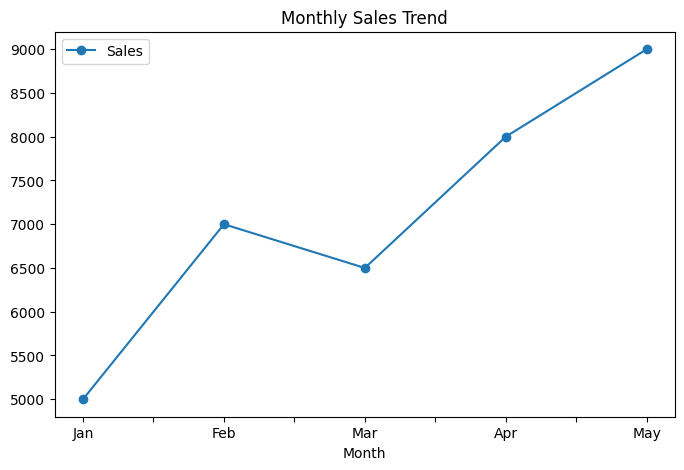

In [57]:
df.plot(
    x="Month",
    y="Sales",
    kind="line",
    marker="o",
    figsize=(8,5),
    title="Monthly Sales Trend"
)

plt.show()

Explanation
x="Month" → X-axis
y="Sales" → Y-axis
kind="line" → Line chart
marker="o" → Circle markers
figsize=(8,5) → Chart size
title= → Chart title

2. Bar Chart
Best For:

Comparing values across categories.

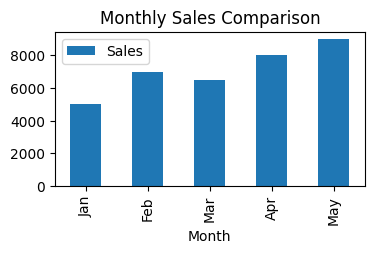

In [64]:
df.plot(
    x="Month",
    y="Sales",
    kind="bar",
    figsize=(4,2),
    title="Monthly Sales Comparison"
)

plt.show()

3. Horizontal Bar Chart
Best For:

Long category names.

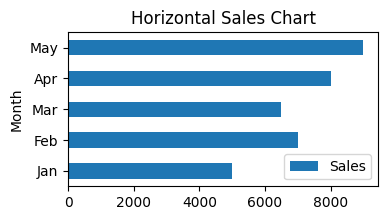

In [66]:
df.plot(
    x="Month",
    y="Sales",
    kind="barh",
    figsize=(4,2),
    title="Horizontal Sales Chart"
)

plt.show()

4. Pie Chart
Best For:

Showing percentage contribution.

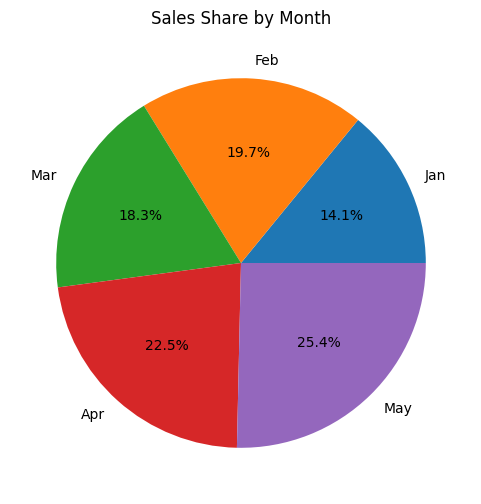

In [ ]:
df.set_index("Month")["Sales"].plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6),
    title="Sales Share by Month"
)
plt.ylabel("")
plt.show()

Explanation
autopct="%1.1f%%" → Show percentages
set_index("Month") → Use month names as labels

5. Histogram
Best For:

Understanding data distribution.

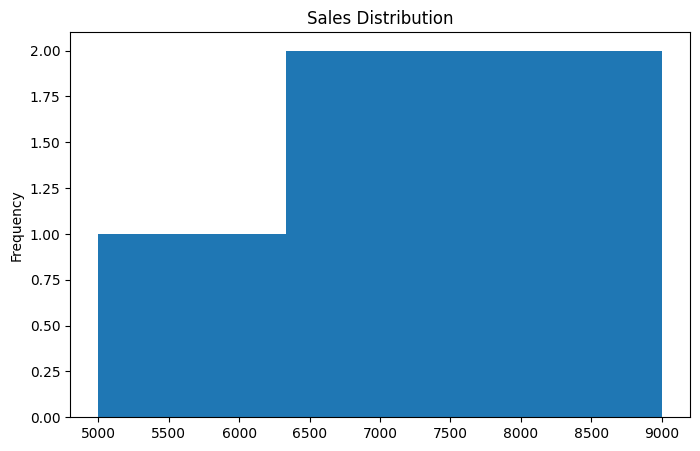

In [71]:
df["Sales"].plot(
    kind="hist",
    bins=3,
    figsize=(8,5),
    title="Sales Distribution"
)

plt.show()

Explanation
bins=5 divides data into 5 groups.

6. Scatter Plot
Best For:

Finding relationships between two numerical columns.

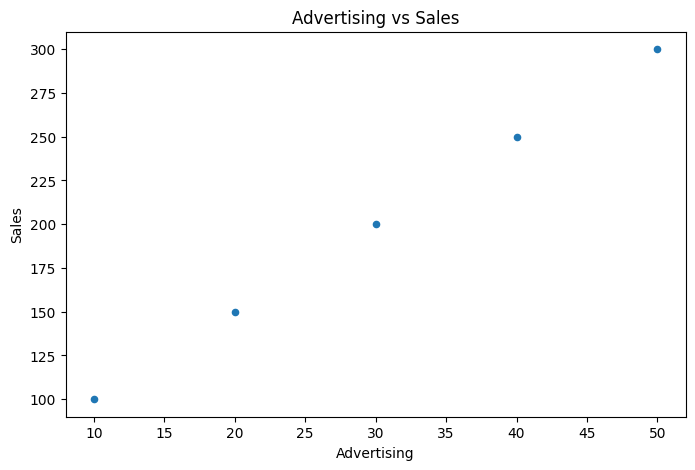

In [74]:
data = {
    "Advertising": [10,20,30,40,50],
    "Sales": [100,150,200,250,300]
}

df2 = pd.DataFrame(data)

df2.plot(
    x="Advertising",
    y="Sales",
    kind="scatter",
    figsize=(8,5),
    title="Advertising vs Sales"
)

plt.show()

Interpretation

As advertising increases, sales also increase.

7. Box Plot
Best For:

Finding spread, median, and outliers.

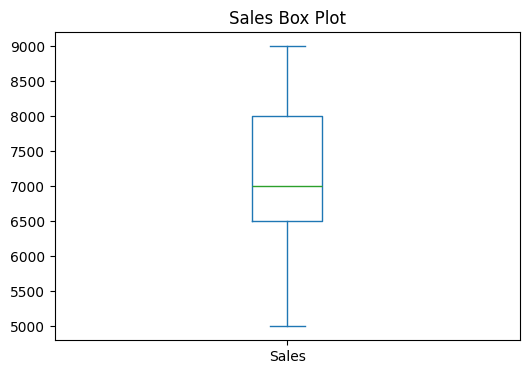

In [75]:
df["Sales"].plot(
    kind="box",
    figsize=(6,4),
    title="Sales Box Plot"
)

plt.show()

Box Plot Shows
Minimum Value
Maximum Value
Median
Quartiles (Q1, Q3)
Outliers

Real-World Example: Company Department Sales

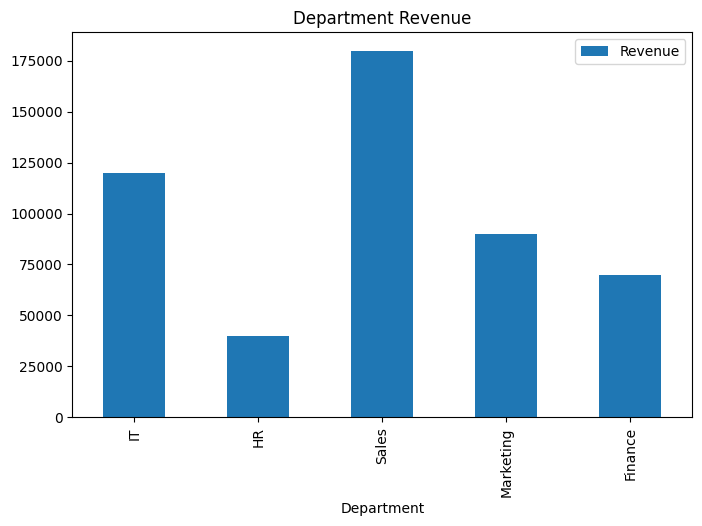

In [76]:
company = {
    "Department": ["IT", "HR", "Sales", "Marketing", "Finance"],
    "Revenue": [120000, 40000, 180000, 90000, 70000]
}

dept_df = pd.DataFrame(company)

dept_df.plot(
    x="Department",
    y="Revenue",
    kind="bar",
    figsize=(8,5),
    title="Department Revenue"
)

plt.show()

Student Practice Exercises
Exercise 1

Create a DataFrame:

In [77]:
students = {
    "Name": ["A", "B", "C", "D"],
    "Marks": [75, 85, 65, 90]
}

Create:

Bar Chart
Pie Chart

Exercise 2

Create a line chart showing:

In [ ]:
Days = ["Mon","Tue","Wed","Thu","Fri"]
Visitors = [100,120,150,180,200]

Exercise 3

Create a histogram for:

In [ ]:
Marks = [45,50,55,60,65,70,75,80,85,90]

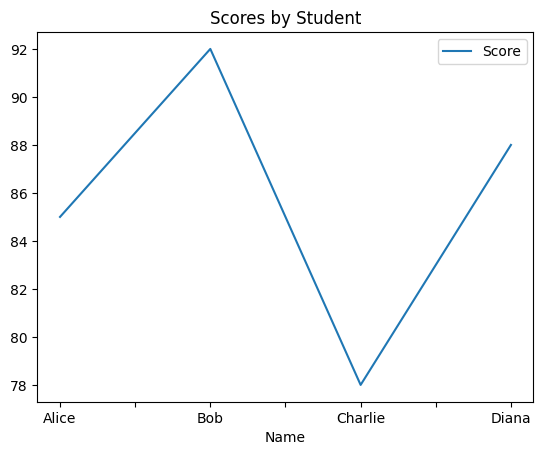

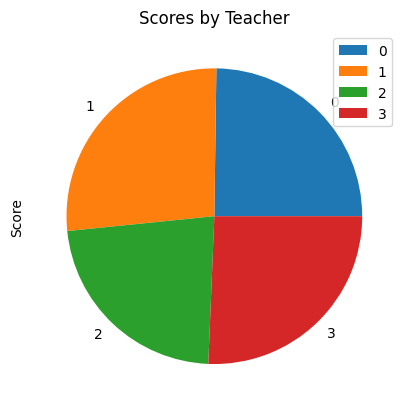

In [44]:

df.plot(
    kind='line',
    x='Name',
    y='Score',
    title='Scores by Student'
)

df.plot(
    kind='pie',
    x='Name',
    y='Score',
    title='Scores by Teacher'
)

plt.show()



---
## STEP 15 — Sorting & Resetting Index

### `sort_values()` — Sort Rows

```python
df.sort_values('Score', ascending=True)   # Low to High
df.sort_values('Score', ascending=False)  # High to Low (Top performers first)
df.sort_values(['City', 'Score'])         # Sort by City first, then Score
```

**Real-world use:** Sort sales by revenue to find top products, sort employees by salary.

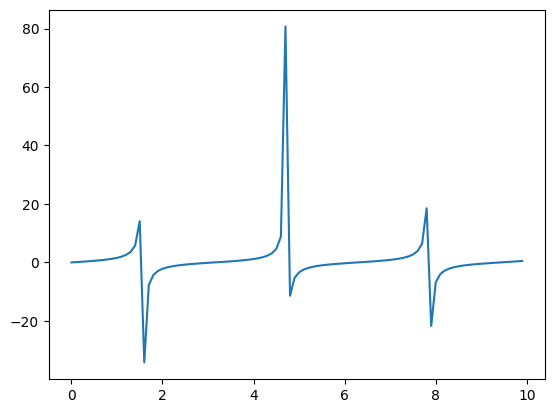

In [45]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 10, 0.1)
y = np.tan(x)
plt.plot(x, y)
plt.show()

In [46]:

df_sorted = df.sort_values(
    'Name',
    ascending=True
)

print(df_sorted)


      Name  Age     City  Score  Bonus  Score_Squared  Age_Next_Year Grade  \
0    Alice   25      NYC     85    8.5           7225             26     B   
1      Bob   30       LA     92    9.2           8464             31     A   
2  Charlie   35  Chicago     78    7.8           6084             36     C   
3    Diana   28      NYC     88    8.8           7744             29     B   

   Sum_Cols  
0       110  
1       122  
2       113  
3       116  


In [47]:

filtered = df[df['Score'] > 80].reset_index(
    drop=True
)

print(filtered)


    Name  Age City  Score  Bonus  Score_Squared  Age_Next_Year Grade  Sum_Cols
0  Alice   25  NYC     85    8.5           7225             26     B       110
1    Bob   30   LA     92    9.2           8464             31     A       122
2  Diana   28  NYC     88    8.8           7744             29     B       116


### `reset_index()` — Fix Broken Row Numbers

After **filtering**, the original row numbers remain (e.g., 0, 1, 3 — row 2 was filtered out).

`reset_index(drop=True)` creates clean new index: 0, 1, 2, 3...

`drop=True` → don't add the old index as a new column

---
## STEP 16 — Real-World Project: Employee Salary Analysis

### Problem Statement
HR department gives you employee data.  
They want to know:
1. What is each employee's **increment amount**?
2. What is their **new salary** after the hike?

### Formula
```
Increment Amount = Salary × (Hike % / 100)
New Salary       = Salary + Increment Amount
```

This is exactly what companies do every appraisal cycle!

In [48]:

salary_data = {
    'Employee': ['A', 'B', 'C', 'D'],
    'Salary': [25000, 30000, 40000, 50000],
    'Hike_Percentage': [12, 3, 7, 15]
}

salary_df = pd.DataFrame(salary_data)

salary_df['Increment_Amount'] = (
    salary_df['Salary']
    * salary_df['Hike_Percentage']
    / 100
)

salary_df['New_Salary'] = (
    salary_df['Salary']
    + salary_df['Increment_Amount']
)

print(salary_df)


  Employee  Salary  Hike_Percentage  Increment_Amount  New_Salary
0        A   25000               12            3000.0     28000.0
1        B   30000                3             900.0     30900.0
2        C   40000                7            2800.0     42800.0
3        D   50000               15            7500.0     57500.0


---
## Homework Exercises

### Exercise 1 — Student Analysis
Create a student DataFrame with columns: `Name`, `Marks`, `Subject`, `City`
- Filter students with Marks > 80
- Sort by Marks descending
- Display the top 3 students

---

### Exercise 2 — Sales Report
Create sales data for 3 products across 4 regions.
- Use `groupby` to find total sales per region
- Create a pivot table: Products as rows, Regions as columns, Sales as values
- Which region has the highest total sales?

---

### Exercise 3 — Data Cleaning
Create a DataFrame with 10 rows, intentionally add `NaN` values in some cells.
- Count missing values per column
- Fill numeric columns with their median
- Drop rows where more than 2 values are missing

---

### Exercise 4 — Salary Calculator
Create employee data with: `Name`, `Department`, `Current_Salary`, `Rating`

Rating-based hike:
- Rating 5 → 20% hike
- Rating 4 → 12% hike
- Rating 3 → 7% hike
- Rating 1 or 2 → 0% hike

Calculate and display each employee's new salary.

---
## Summary — What You Mastered Today

| Topic | Key Function | One-Line Summary |
|-------|-------------|-----------------|
| Series | `pd.Series()` | 1D labeled array |
| DataFrame | `pd.DataFrame()` | 2D table (rows + columns) |
| File I/O | `read_csv()`, `to_csv()` | Load and save data files |
| Inspect | `head()`, `info()`, `describe()` | Understand your data |
| Select | `df['col']`, `loc`, `iloc` | Pick rows and columns |
| Filter | `df[condition]` | Keep only matching rows |
| Missing | `fillna()`, `dropna()` | Handle NaN values |
| Operate | `df['new'] = df['col'] * x` | Create derived columns |
| GroupBy | `groupby().agg()` | Summarize by groups |
| Merge | `pd.merge()` | Join two tables |
| Pivot | `pivot_table()` | Matrix summary |
| Apply | `apply(func)` / `lambda` | Custom operations |
| Time | `date_range()`, `resample()` | Date-based analysis |
| Plot | `.plot(kind='...')` | Quick charts |
| Sort | `sort_values()` | Rank data |

---

## You Are Now Ready To:
- Analyze real CSV files from companies
- Answer business questions with data
- Build simple reports and dashboards
- Apply for Junior Data Analyst roles

**Next Step →** Practice with real datasets from Kaggle.com

In [49]:
new_df=pd.DataFrame({
    "name":[''],
     "marks":['']
})